<a href="https://colab.research.google.com/github/hetalsharmaaa/perzonix/blob/main/laptoprecommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [3]:
uncleaned = pd.read_csv("laptops_uncleaned.csv")
cleaned   = pd.read_csv("laptops_cleaned.csv")

In [5]:
print(f"Uncleaned dataset : {uncleaned.shape[0]} rows, {uncleaned.shape[1]} columns")
print(f"Cleaned dataset   : {cleaned.shape[0]} rows, {cleaned.shape[1]} columns")

Uncleaned dataset : 1020 rows, 12 columns
Cleaned dataset   : 1018 rows, 22 columns


In [6]:
print("\n--- Uncleaned Columns ---")
print(uncleaned.columns.tolist())


--- Uncleaned Columns ---
['Unnamed: 0', 'model', 'price', 'rating', 'processor', 'core', 'ram', 'memory', 'graphic_card', 'display', 'os', 'warrenty']


In [7]:
print("\n--- cleaned Columns ---")
print(cleaned.columns.tolist())


--- cleaned Columns ---
['index', 'brand_name', 'model', 'price', 'rating', 'processor', 'processor_brand', 'iter', 'ram', 'threads_num', 'core_num', 'ram_num', 'memory_type', 'memory_size', 'gpu_brand', 'gpu_type', 'os', 'display_size', 'resolutioin_height', 'resolutioin_width', 'Touch_Screen', 'warrenty']


In [8]:
print("\n--- First 3 rows of UNCLEANED data ---")
print(uncleaned.head(3).to_string())


--- First 3 rows of UNCLEANED data ---
   Unnamed: 0                                                                                              model    price  rating                     processor                            core               ram      memory         graphic_card                          display             os         warrenty
0           0                  Lenovo V15 G4 ‎83CR000VIN Laptop (AMD Ryzen 7 7730U/ 16GB/ 512GB SSD/ Win11 Home)  ₹39,990     4.5     7th Gen AMD Ryzen 7 7730U           Octa Core, 16 Threads    16 GB DDR4 RAM  512 GB SSD  AMD Radeon Graphics  15.6 inches, 1920 x 1080 pixels  Windows 11 OS  1 Year Warranty
1           1  Samsung Galaxy Book 4 NP750XGJ-LG4IN Laptop (13th Gen Intel Core i3-1315U/ 8GB/ 512GB SSD/ Win11)  ₹36,990     4.4  13th Gen Intel Core i3 1315U  Hexa Core (2P + 4E), 8 Threads  8 GB LPDDR4x RAM  512 GB SSD       Intel Graphics  15.6 inches, 1920 x 1080 pixels  Windows 11 OS  1 Year Warranty
2           2                       

In [9]:
print("\n--- First 3 rows of CLEANED data ---")
print(cleaned.head(3).to_string())


--- First 3 rows of CLEANED data ---
   index brand_name                                                                                              model  price  rating                     processor processor_brand     iter               ram  threads_num  core_num  ram_num memory_type  memory_size gpu_brand    gpu_type          os  display_size  resolutioin_height  resolutioin_width  Touch_Screen  warrenty
0      2     Lenovo                  Lenovo V15 G4 ‎83CR000VIN Laptop (AMD Ryzen 7 7730U/ 16GB/ 512GB SSD/ Win11 Home)  39990     4.5     7th Gen AMD Ryzen 7 7730U             AMD  Ryzen 7    16 GB DDR4 RAM         16.0       8.0       16         SSD          512       AMD  Integrated  Windows 11          15.6                1920               1080         False         1
1      3    Samsung  Samsung Galaxy Book 4 NP750XGJ-LG4IN Laptop (13th Gen Intel Core i3-1315U/ 8GB/ 512GB SSD/ Win11)  36990     4.4  13th Gen Intel Core i3 1315U           Intel  Core i3  8 GB LPDDR4x RAM      

In [10]:
print("\n--- Missing Values in UNCLEANED ---")
print(uncleaned.isnull().sum()[uncleaned.isnull().sum() > 0])


--- Missing Values in UNCLEANED ---
warrenty    3
dtype: int64


In [11]:
print("\n--- Missing Values in CLEANED ---")
print(cleaned.isnull().sum()[cleaned.isnull().sum() > 0])


--- Missing Values in CLEANED ---
threads_num    77
core_num       22
dtype: int64


In [12]:
print("\n--- Key Statistics (Cleaned) ---")
print(f"Brands          : {cleaned['brand_name'].nunique()} unique | Top 5: {cleaned['brand_name'].value_counts().head(5).to_dict()}")
print(f"Price range     : ₹{cleaned['price'].min():,} – ₹{cleaned['price'].max():,}")
print(f"Rating range    : {cleaned['rating'].min()} – {cleaned['rating'].max()}")
print(f"RAM range       : {cleaned['ram_num'].min()}GB – {cleaned['ram_num'].max()}GB")
print(f"GPU types       : {cleaned['gpu_type'].value_counts().to_dict()}")
print(f"Processor brands: {cleaned['processor_brand'].value_counts().to_dict()}")
print(f"OS breakdown    : {cleaned['os'].value_counts().head(5).to_dict()}")


--- Key Statistics (Cleaned) ---
Brands          : 29 unique | Top 5: {'HP': 215, 'Lenovo': 204, 'Asus': 170, 'Acer': 119, 'MSI': 109}
Price range     : ₹10,990 – ₹500,990
Rating range    : 4.0 – 4.75
RAM range       : 4GB – 96GB
GPU types       : {'Integrated': 617, 'Dedicated': 401}
Processor brands: {'Intel': 745, 'AMD': 206, 'Qualcomm': 28, 'Apple': 23, 'MediaTek': 8, 'Other': 8}
OS breakdown    : {'Windows 11': 957, 'Mac': 23, 'Chrome': 20, 'DOS': 10, 'Windows 10': 2}


Text(0.5, 0.98, 'EDA — Laptop Dataset Overview')

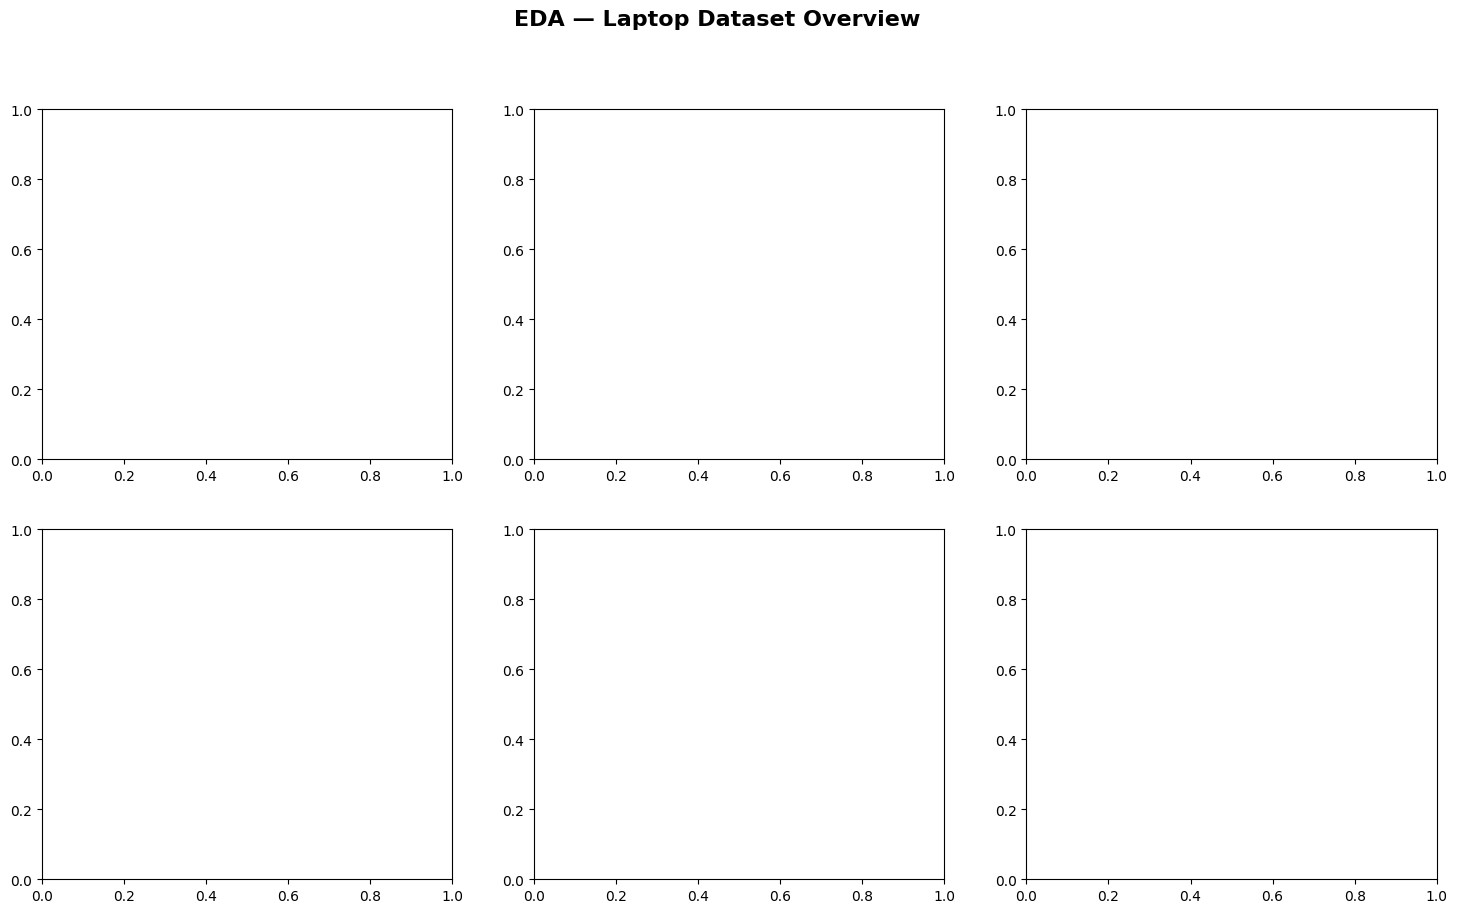

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Laptop Dataset Overview", fontsize=16, fontweight="bold")

In [14]:
axes[0, 0].hist(cleaned["price"], bins=30, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price (₹)")
axes[0, 0].set_ylabel("Count")

Text(4.444444444444452, 0.5, 'Count')

In [15]:
brand_counts = cleaned["brand_name"].value_counts().head(10)
axes[0, 1].barh(brand_counts.index[::-1], brand_counts.values[::-1], color="coral")
axes[0, 1].set_title("Top 10 Brands")
axes[0, 1].set_xlabel("Number of Laptops")

Text(0.5, 424.44444444444446, 'Number of Laptops')

In [16]:
ram_counts = cleaned["ram_num"].value_counts().sort_index()
axes[0, 2].bar(ram_counts.index.astype(str), ram_counts.values, color="mediumseagreen")
axes[0, 2].set_title("RAM Distribution")
axes[0, 2].set_xlabel("RAM (GB)")
axes[0, 2].set_ylabel("Count")

Text(989.1503267973857, 0.5, 'Count')

In [17]:
gpu_counts = cleaned["gpu_type"].value_counts()
axes[1, 0].pie(gpu_counts.values, labels=gpu_counts.index, autopct="%1.1f%%",
               colors=["#4C72B0", "#DD8452"])
axes[1, 0].set_title("GPU Type Split")

Text(0.5, 1.0, 'GPU Type Split')

In [18]:
axes[1, 1].hist(cleaned["rating"], bins=15, color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("Rating Distribution")
axes[1, 1].set_xlabel("Rating")
axes[1, 1].set_ylabel("Count")

Text(496.7973856209152, 0.5, 'Count')

In [19]:
axes[1, 2].scatter(cleaned["ram_num"], cleaned["price"] / 1000,
                   alpha=0.4, color="tomato", s=20)
axes[1, 2].set_title("Price vs RAM")
axes[1, 2].set_xlabel("RAM (GB)")
axes[1, 2].set_ylabel("Price (₹ thousands)")

Text(989.1503267973857, 0.5, 'Price (₹ thousands)')

In [20]:
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n[EDA complete — plot saved as eda_plots.png]")

<Figure size 640x480 with 0 Axes>


[EDA complete — plot saved as eda_plots.png]


In [21]:
print("[STEP 2] Cleaning & Preprocessing Data...")

[STEP 2] Cleaning & Preprocessing Data...


In [22]:
df = cleaned.copy()

In [23]:
df = df.drop(columns=["index"], errors="ignore")

In [24]:
df["os"] = df["os"].replace({
    "Windows 10": "Windows",
    "Windows 11": "Windows",
    "DOS":         "Other",
    "DOS 3.0":     "Other",
    "Ubuntu":      "Other",
    "Linux":       "Other",
    "Backlit Keyboard": "Other"
})

In [25]:
df["threads_num"] = df["threads_num"].fillna(df["threads_num"].median())
df["core_num"]    = df["core_num"].fillna(df["core_num"].median())
df["display_size"] = df["display_size"].fillna(df["display_size"].median())

In [28]:
df = df.reset_index(drop=True)
df["laptop_id"] = df.index
df["laptop_label"] = df["brand_name"] + " " + df["model"].str[:30]

In [29]:
print(f"Rows after cleaning  : {len(df)}")
print(f"Columns              : {df.columns.tolist()}")
print(f"Remaining nulls      : {df.isnull().sum().sum()}")
print("\nSample cleaned rows:")
print(df[["laptop_label", "price", "ram_num", "gpu_type",
          "processor_brand", "display_size", "rating"]].head(5).to_string())

Rows after cleaning  : 1018
Columns              : ['brand_name', 'model', 'price', 'rating', 'processor', 'processor_brand', 'iter', 'ram', 'threads_num', 'core_num', 'ram_num', 'memory_type', 'memory_size', 'gpu_brand', 'gpu_type', 'os', 'display_size', 'resolutioin_height', 'resolutioin_width', 'Touch_Screen', 'warrenty', 'laptop_id', 'laptop_label']
Remaining nulls      : 0

Sample cleaned rows:
                             laptop_label   price  ram_num    gpu_type processor_brand  display_size  rating
0   Lenovo Lenovo V15 G4 ‎83CR000VIN Lapt   39990       16  Integrated             AMD          15.6    4.50
1  Samsung Samsung Galaxy Book 4 NP750XGJ   36990        8  Integrated           Intel          15.6    4.40
2       HP HP 15-fc0154AU Laptop (AMD Ryz   30290        8  Integrated             AMD          15.6    4.70
3      MSI MSI Titan 18 HX Gaming Laptop   359900       32   Dedicated           Intel          18.0    4.75
4     Asus Asus Vivobook 16X 2023 K3605ZC   59140   

In [30]:
print("\n--- What Changed from Uncleaned → Cleaned ---")
print(f"  'price' was: {uncleaned['price'].iloc[0]}  →  now: {df['price'].iloc[0]}")
print(f"  'ram'   was: {uncleaned['ram'].iloc[0]}    →  now: {df['ram_num'].iloc[0]} GB (numeric)")
print(f"  'os'   standardized, columns split into brand/model/GPU fields")


--- What Changed from Uncleaned → Cleaned ---
  'price' was: ₹39,990  →  now: 39990
  'ram'   was: 16 GB DDR4 RAM    →  now: 16 GB (numeric)
  'os'   standardized, columns split into brand/model/GPU fields


In [31]:
print("[STEP 3] Feature Engineering for Content-Based Filtering...")

[STEP 3] Feature Engineering for Content-Based Filtering...


In [32]:
num_features = ["price", "ram_num", "memory_size", "display_size",
                "core_num", "threads_num", "rating"]

In [33]:
cat_features = ["brand_name", "processor_brand", "gpu_type",
                "os", "memory_type", "Touch_Screen"]

In [34]:
df_encoded = pd.get_dummies(df[cat_features], drop_first=False)

In [35]:
scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(
    scaler.fit_transform(df[num_features]),
    columns=num_features
)

In [36]:
feature_matrix = pd.concat([df_num_scaled, df_encoded.astype(float)], axis=1)

In [37]:
print(f"Feature matrix shape : {feature_matrix.shape}")
print(f"  → {len(num_features)} numerical features (normalized)")
print(f"  → {df_encoded.shape[1]} one-hot encoded categorical features")
print(f"  → Total: {feature_matrix.shape[1]} features per laptop")

Feature matrix shape : (1018, 52)
  → 7 numerical features (normalized)
  → 45 one-hot encoded categorical features
  → Total: 52 features per laptop


In [38]:
print("[STEP 4] Content-Based Filtering (Cosine Similarity)...")

[STEP 4] Content-Based Filtering (Cosine Similarity)...


In [39]:
feature_array = feature_matrix.values
cosine_sim_matrix = cosine_similarity(feature_array)

In [40]:
print(f"Cosine similarity matrix shape: {cosine_sim_matrix.shape}")
print(f"  → Every cell [i][j] = similarity between laptop i and laptop j")
print(f"  → Diagonal is always 1.0 (a laptop is identical to itself)")

Cosine similarity matrix shape: (1018, 1018)
  → Every cell [i][j] = similarity between laptop i and laptop j
  → Diagonal is always 1.0 (a laptop is identical to itself)


In [42]:
def content_based_recommend(laptop_idx, top_n=5, df=df, sim_matrix=cosine_sim_matrix):
    """
    Returns top_n laptops most similar to the given laptop_idx
    based on cosine similarity of their feature vectors.
    """
    sim_scores = list(enumerate(sim_matrix[laptop_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n + 1]

    result_rows = []
    for idx, score in sim_scores:
        row = df.iloc[idx]
        result_rows.append({
            "Laptop"      : row["laptop_label"],
            "Brand"       : row["brand_name"],
            "Price (₹)"   : f"₹{row['price']:,}",
            "RAM (GB)"    : row["ram_num"],
            "GPU"         : row["gpu_type"],
            "Processor"   : row["processor_brand"],
            "Display"     : row["display_size"],
            "Rating"      : row["rating"],
            "Similarity"  : round(score, 4)
        })
    return pd.DataFrame(result_rows)

In [43]:
print("\n--- Content-Based Demo ---")
query_laptop = df.iloc[0]
print(f"Query laptop: {query_laptop['laptop_label']} | "
      f"₹{query_laptop['price']:,} | {query_laptop['ram_num']}GB RAM | "
      f"{query_laptop['gpu_type']} GPU | {query_laptop['processor_brand']} CPU")
print("\nTop 5 similar laptops:")
cb_results = content_based_recommend(0, top_n=5)
print(cb_results.to_string(index=False))


--- Content-Based Demo ---
Query laptop: Lenovo Lenovo V15 G4 ‎83CR000VIN Lapt | ₹39,990 | 16GB RAM | Integrated GPU | AMD CPU

Top 5 similar laptops:
                               Laptop  Brand Price (₹)  RAM (GB)        GPU Processor  Display  Rating  Similarity
Lenovo Lenovo IdeaPad 1 15ALC7 82R400 Lenovo   ₹38,000        16 Integrated       AMD     15.6    4.60      0.9971
Lenovo Lenovo IdeaPad Slim 1 82R400BG Lenovo   ₹34,100         8 Integrated       AMD     15.6    4.60      0.9965
Lenovo Lenovo ThinkBook 16 G6 21KKA0G Lenovo   ₹54,989        16 Integrated       AMD     16.0    4.30      0.9938
Lenovo Lenovo V15 G4 ‎83CQ0006IN Lapt Lenovo   ₹26,490         8 Integrated       AMD     15.6    4.55      0.9931
Lenovo Lenovo ThinkPad E14 21JRS0JH00 Lenovo   ₹48,990         8 Integrated       AMD     14.0    4.55      0.9925
